In [ ]:
# Using the single discriminant function g(x), write Python function to design a 2-
# class minimum-error-rate classifier from the given data to classify samples into either Class 0
# or Class 1.

import numpy as np
from sklearn.datasets import load_iris

# 1) Load Iris data
iris = load_iris()
X = iris.data          # 150 rows, 4 features
y = iris.target        # labels: 0=setosa, 1=versicolor, 2=virginica

# 2) Keep only Class 0 and Class 1 (remove Class 2)
rows = []
for i in range(len(y)):
    if y[i] == 0 or y[i] == 1:
        rows.append(i)

X01 = X[rows, :]
y01 = y[rows]

# Petal length (column index 2)
x = X01[:, 2]

x0 = x[y01 == 0]   # petal lengths for Class 0 (setosa)
x1 = x[y01 == 1]   # petal lengths for Class 1 (versicolor)

# Priors (probability of w0 and w1)
P0 = len(x0) / len(x)   # P(w0)
P1 = len(x1) / len(x)   # P(w1)

# 6) Gaussian parameters from data
mu0 = np.mean(x0)       # mean petal length for Class 0
mu1 = np.mean(x1)       # mean petal length for Class 1

var0 = np.var(x0)       # variance for Class 0
var1 = np.var(x1)       # variance for Class 1


# Discriminant function g(x)
  # g(x) > 0 --> versicolour (w1)
  # g(x) < 0 --> setosa (w0)
def g(x_val): # How likely is x_val to belong to Versicolour (w1) versus Setosa (w0)

    # TERM 1 (data fit): how well x_val matches Class 1's Gaussian
    # Negative sign --> farther = less likely to be w1
    class1_fit = -((x_val - mu1)**2) / (2 * var1)

    # TERM 2 (data fit): how well x_val matches Class 0's Gaussian
    # Small/close to 0 means Setosa,large vals --> closer to Versicolour
    class0_fit = +((x_val - mu0)**2) / (2 * var0)

    # TERM 3 (spread/variance): corrects for different variances (wide vs narrow Gaussians)
    variance_term = -0.5 * np.log(var1 / var0)

    # TERM 4 (priors): if one class is more common, this biases the decision toward it
    prior_term = np.log(P1 / P0)

    # Add them all: this equals ln[p(x|w1)P(w1)] - ln[p(x|w0)P(w0)]
    return class1_fit + class0_fit + variance_term + prior_term # +ve = w1, -ve = w0

# Decision Rule: check sign of discriminant (g(x)) from above
def predict(x_val):
    return 1 if g(x_val) > 0 else 0  # 1=versicolour, 0=setosa

# Test Run
test_x = 3 # petal length in cm
print("\nExample test:")
print("test_x =", test_x)
print("g(test_x) =", g(test_x))
print("Predicted class =", predict(test_x))

# Verify Values
print("Estimated parameters:")
print("Class 0: mu0 =", mu0, "var0 =", var0, "P0 =", P0)
print("Class 1: mu1 =", mu1, "var1 =", var1, "P1 =", P1)


Example test:
test_x = 3
g(test_x) = 35.352680112390686
Predicted class = 1
Estimated parameters:
Class 0: mu0 = 1.4620000000000002 var0 = 0.029555999999999995 P0 = 0.5
Class 1: mu1 = 4.26 var1 = 0.21640000000000004 P1 = 0.5


In [ ]:
# Write a Python program that takes the feature as input and returns the posterior
# probabilities and the value of g(x) using the previous step.

import numpy as np
from sklearn.datasets import load_iris

# 1) Load Iris
iris = load_iris()
X = iris.data
y = iris.target

# 2) Keep only class 0 and 1
rows = []
for i in range(len(y)):
    if y[i] == 0 or y[i] == 1:
        rows.append(i)

X01 = X[rows, :]
y01 = y[rows]

# 3) Use petal length (feature index 2)
x = X01[:, 2]

# 4) Split petal length by class
x0 = x[y01 == 0]
x1 = x[y01 == 1]

# 5) Prior probabilities (how common each class is in the dataset)
P0 = len(x0) / len(x)
P1 = len(x1) / len(x)

# 6) Gaussian parameters (mean and variance for each class)
mu0 = np.mean(x0)
mu1 = np.mean(x1)
var0 = np.var(x0)
var1 = np.var(x1)


# Gaussian PDF (probability density): If a class has mean mu and variance var, how likely is it to produce x_val
def gaussian_pdf(x_val, mu, var):
    return (1 / np.sqrt(2 * np.pi * var)) * np.exp(-((x_val - mu) ** 2) / (2 * var))

# Single discriminant function g(x): ln[p(x|w1)p(w1)]-ln[p(x|w0)p(w0)]
# Positive --> looks more like Versicolour
# Negative --> looks more like Setosa
def g(x_val):
    return np.log(gaussian_pdf(x_val, mu1, var1) * P1) - np.log(gaussian_pdf(x_val, mu0, var0) * P0)

# Posterior probabilities P(w0|x) and P(w1|x)
def posteriors(x_val):
    px_w0 = gaussian_pdf(x_val, mu0, var0) # p(x|w0)
    px_w1 = gaussian_pdf(x_val, mu1, var1) # p(x|w1)

    numerator0 = px_w0 * P0 # p(x|w0)p(w0)
    numerator1 = px_w1 * P1 # p(x|w1)p(w1)
    denom = numerator0 + numerator1

    # Posterior Probabilities (to see how confident the class is about the decision)
    Pw0_given_x = numerator0 / denom # P(w0|x)
    Pw1_given_x = numerator1 / denom # P(w1|x)

    return Pw0_given_x, Pw1_given_x

# Input + output
x_in = float(input("Enter petal length value: "))

Pw0, Pw1 = posteriors(x_in)
gx = g(x_in)

print("\nResults:")
print("g(x) =", gx)
print("P(Class 0 | x) =", Pw0)
print("P(Class 1 | x) =", Pw1)

if gx > 0:
    print("Predicted class: 1")
else:
    print("Predicted class: 0")


Enter petal length value: 0

Results:
g(x) = -6.76688163811567
P(Class 0 | x) = 0.9988500447553571
P(Class 1 | x) = 0.001149955244642822
Predicted class: 0


Optimal threshold = 2.245141505016604


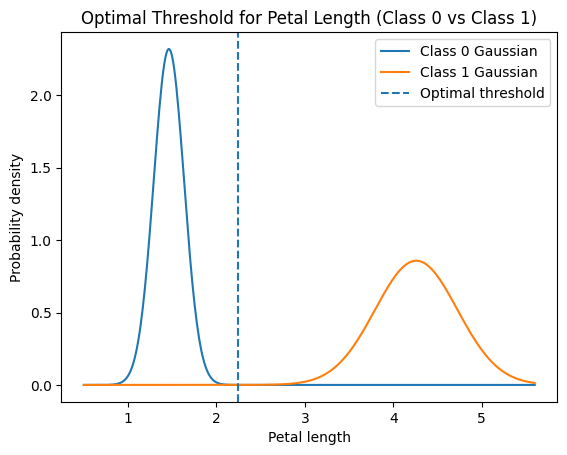

In [ ]:
#Determine the optimal threshold μ1 that separates classes w0 and w1. Plot and
#report the optimal optimal threshold μ1

import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import load_iris

# -----------------------------
# 1) Load data and keep classes 0 and 1
# -----------------------------
iris = load_iris()
X = iris.data
y = iris.target

rows = []
for i in range(len(y)):
    if y[i] == 0 or y[i] == 1:
        rows.append(i)

X01 = X[rows, :]
y01 = y[rows]

# -----------------------------
# 2) Choose petal length (feature index 2)
# -----------------------------
x = X01[:, 2]
x0 = x[y01 == 0]   # class 0
x1 = x[y01 == 1]   # class 1

# -----------------------------
# 3) Compute priors, means, variances
# -----------------------------
P0 = len(x0) / len(x)
P1 = len(x1) / len(x)

mu0 = np.mean(x0)
mu1 = np.mean(x1)

var0 = np.var(x0)
var1 = np.var(x1)

# Find threshold(s): solve g(x)=0
# This becomes: a*x^2 + b*x + c = 0
a = (1/(2*var0)) - (1/(2*var1))
b = (-mu0/var0) + (mu1/var1)
c = (mu0**2)/(2*var0) - (mu1**2)/(2*var1) + 0.5*np.log(var0/var1) + np.log(P0/P1)

thresholds = []

# If a is ~0, it's basically a linear equation
if abs(a) < 1e-12:
    # b*x + c = 0
    t = -c / b
    thresholds = [t]
else:
    disc = b**2 - 4*a*c
    if disc >= 0:
        t1 = (-b + np.sqrt(disc)) / (2*a)
        t2 = (-b - np.sqrt(disc)) / (2*a)
        thresholds = [t1, t2]

# Choose the "best" threshold (usually the one between the two means)
best_threshold = None
low = min(mu0, mu1)
high = max(mu0, mu1)

for t in thresholds:
    if low < t < high:
        best_threshold = t

# If none are between the means, pick the one closest to the midpoint
if best_threshold is None and len(thresholds) > 0:
    midpoint = 0.5 * (mu0 + mu1)
    best_threshold = min(thresholds, key=lambda z: abs(z - midpoint))

# print("mu0 =", mu0, "mu1 =", mu1)
print("Optimal threshold =", best_threshold)

# Plot the two Gaussian PDFs + the threshold line
def gaussian_pdf(x_val, mu, var):
    return (1/np.sqrt(2*np.pi*var)) * np.exp(-((x_val - mu)**2)/(2*var))

x_min = min(x) - 0.5
x_max = max(x) + 0.5
xs = np.linspace(x_min, x_max, 400)

pdf0 = gaussian_pdf(xs, mu0, var0)
pdf1 = gaussian_pdf(xs, mu1, var1)

plt.figure()
plt.plot(xs, pdf0, label="Class 0 Gaussian")
plt.plot(xs, pdf1, label="Class 1 Gaussian")

if best_threshold is not None:
    plt.axvline(best_threshold, linestyle="--", label="Optimal threshold")

plt.title("Optimal Threshold for Petal Length (Class 0 vs Class 1)")
plt.xlabel("Petal length")
plt.ylabel("Probability density")
plt.legend()
plt.show()


Petal length statistics:
w0 (setosa):      mean = 1.4620000000000002 std = 0.17366399648018407
w1 (versicolour): mean = 4.26 std = 0.46991097723995795
Penalty = 1  --> μ2 = 2.2457085940611003
Penalty = 2  --> μ2 = 2.225801965889901
Penalty = 5  --> μ2 = 2.198972450777405
Penalty = 10  --> μ2 = 2.178267160494771
Penalty = 20  --> μ2 = 2.1571778298812103
Penalty = 50  --> μ2 = 2.1286951436789185


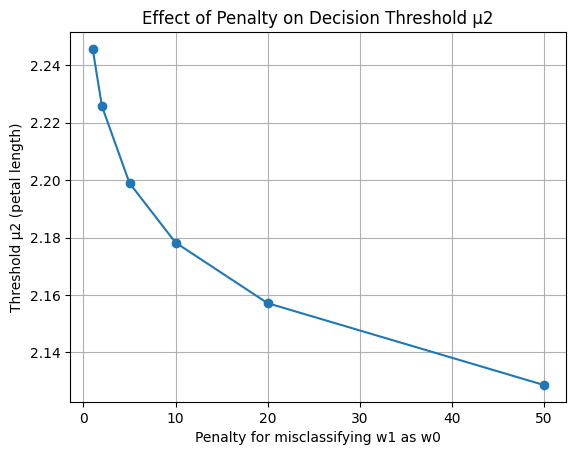

In [ ]:
# Determine a second threshold μ2 when a high penalty is assigned for mis-classifying
# w1 as w0. Plot and report the threshold μ2 with different penalties


import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import load_iris

# Load the Iris dataset
iris = load_iris()
X = iris.data      # all feature values
y = iris.target    # class labels (0, 1, 2)

# We ONLY want class 0 (setosa) and class 1 (versicolour)
rows = []

for i in range(len(y)):
    if y[i] == 0 or y[i] == 1:
        rows.append(i)

X01 = X[rows, :]   # features for classes 0 and 1
y01 = y[rows]      # labels for classes 0 and 1


# Choose ONE feature (petal length)
# Feature numbers:
# 0 = sepal length
# 1 = sepal width
# 2 = petal length  <--
# 3 = petal width

feature_index = 2
x = X01[:, feature_index]   # 1D list of petal lengths

# Separate the two classes
# w0 = setosa (class 0)
# w1 = versicolour (class 1)

x_w0 = x[y01 == 0]
x_w1 = x[y01 == 1]

# Compute basic statistics
# Mean = average
# Std = spread

mu0 = np.mean(x_w0)
sigma0 = np.std(x_w0, ddof=1)

mu1 = np.mean(x_w1)
sigma1 = np.std(x_w1, ddof=1)

print("Petal length statistics:")
print("w0 (setosa):      mean =", mu0, "std =", sigma0)
print("w1 (versicolour): mean =", mu1, "std =", sigma1)

# Class probabilities (priors)
P_w0 = len(x_w0) / len(x)
P_w1 = len(x_w1) / len(x)

# Gaussian probability function
def gaussian(x, mean, std):
    return (1 / (np.sqrt(2 * np.pi) * std)) * np.exp(-0.5 * ((x - mean) / std) ** 2)

# Posterior probabilities
def posterior_probabilities(x_value):

    # Likelihoods
    px_w0 = gaussian(x_value, mu0, sigma0)
    px_w1 = gaussian(x_value, mu1, sigma1)

    # Bayes rule (numerators)
    num0 = px_w0 * P_w0
    num1 = px_w1 * P_w1

    # Normalize
    total = num0 + num1

    P_w0_given_x = num0 / total
    P_w1_given_x = num1 / total

    return P_w0_given_x, P_w1_given_x

# Find decision threshold (μ2)
def find_threshold(penalty):

    # penalty = cost of misclassifying w1 as w0
    cost_01 = penalty
    cost_10 = 1

    # Search across x values
    x_values = np.linspace(min(x) - 0.5, max(x) + 0.5, 4000)

    risks_difference = []

    for value in x_values:
        P0, P1 = posterior_probabilities(value)

        # Expected risks
        risk_w0 = cost_01 * P1
        risk_w1 = cost_10 * P0

        risks_difference.append(risk_w0 - risk_w1)

    risks_difference = np.array(risks_difference)

    # Find where sign changes (crosses zero)
    crossings = np.where(np.sign(risks_difference[:-1]) != np.sign(risks_difference[1:]))[0]

    if len(crossings) == 0:
        return None

    i = crossings[0]

    # Simple interpolation
    x1, x2 = x_values[i], x_values[i+1]
    y1, y2 = risks_difference[i], risks_difference[i+1]

    threshold = x1 - y1 * (x2 - x1) / (y2 - y1)

    return threshold

# Try different penalties
penalties = [1, 2, 5, 10, 20, 50]
thresholds = []

for p in penalties:
    t = find_threshold(p)
    thresholds.append(t)
    print("Penalty =", p, " --> μ2 =", t)

# Plot μ2 vs penalty
plt.figure()
plt.plot(penalties, thresholds, marker='o')
plt.xlabel("Penalty for misclassifying w1 as w0")
plt.ylabel("Threshold μ2 (petal length)")
plt.title("Effect of Penalty on Decision Threshold μ2")
plt.grid(True)
plt.show()


In [ ]:
# Using your program, build a table that shows P(w0|x1), P(w1|x1), g(x1)
# for each of the following test feature values. Then, identify class labels.
# Feature: sepal length (x = 0)

import numpy as np
from sklearn.datasets import load_iris

iris = load_iris()
X = iris.data      # feature values
y = iris.target    # class labels (0,1,2)

# Keep ONLY class 0 and class 1
rows = []
for i in range(len(y)):
    if y[i] == 0 or y[i] == 1:
        rows.append(i)

X01 = X[rows, :]
y01 = y[rows]

# Choose feature = sepal length (x = 0)
feature_index = 0
x = X01[:, feature_index]

# Separate the two classes
x_w0 = x[y01 == 0]   # w0 = Setosa
x_w1 = x[y01 == 1]   # w1 = Versicolour

# Compute mean and standard deviation
mu0 = np.mean(x_w0)
sigma0 = np.std(x_w0, ddof=1)

mu1 = np.mean(x_w1)
sigma1 = np.std(x_w1, ddof=1)

# Class priors
P_w0 = len(x_w0) / len(x)
P_w1 = len(x_w1) / len(x)

# Gaussian PDF function
def gaussian(x, mu, sigma):
    return (1 / (np.sqrt(2 * np.pi) * sigma)) * np.exp(-0.5 * ((x - mu) / sigma) ** 2)

# Posterior probabilities
def posteriors(x_value):
    px_w0 = gaussian(x_value, mu0, sigma0)
    px_w1 = gaussian(x_value, mu1, sigma1)

    num0 = px_w0 * P_w0
    num1 = px_w1 * P_w1

    total = num0 + num1

    P_w0_given_x = num0 / total
    P_w1_given_x = num1 / total

    return P_w0_given_x, P_w1_given_x

# g(x) decision function
# g(x1) = P(w0|x1) - P(w1|x1)
def g_function(x_value):
    P0, P1 = posteriors(x_value)
    return P0 - P1

# Test feature values (CHANGE THESE if needed)
test_values = [3.3, 4.4, 1.2, 5.0, 5.7, 6.3, 1.5]

# Print table header
print("x1\tP(w0|x1)\tP(w1|x1)\tg(x1)\tDecision")
print("-------------------------------------------------------------")

# Compute table values
for x1 in test_values:
    P0, P1 = posteriors(x1)
    g_val = g_function(x1)

    decision = "w0 (Setosa)" if g_val > 0 else "w1 (Versicolour)"
    print(f"{x1:.2f}\t{P0:.4f}\t\t{P1:.4f}\t\t{g_val:.4f}\t{decision}")

# Compute mean and standard deviation
mu0 = np.mean(x_w0)
sigma0 = np.std(x_w0, ddof=1)

mu1 = np.mean(x_w1)
sigma1 = np.std(x_w1, ddof=1)

print("Sepal length statistics:")
print("w0 (Setosa):      mean =", mu0, "std =", sigma0)
print("w1 (Versicolour): mean =", mu1, "std =", sigma1)



x1	P(w0|x1)	P(w1|x1)	g(x1)	Decision
-------------------------------------------------------------
3.30	0.8467		0.1533		0.6935	w0 (Setosa)
4.40	0.9655		0.0345		0.9310	w0 (Setosa)
1.20	0.0000		1.0000		-1.0000	w1 (Versicolour)
5.00	0.8834		0.1166		0.7669	w0 (Setosa)
5.70	0.1897		0.8103		-0.6207	w1 (Versicolour)
6.30	0.0022		0.9978		-0.9956	w1 (Versicolour)
1.50	0.0000		1.0000		-1.0000	w1 (Versicolour)
Sepal length statistics:
w0 (Setosa):      mean = 5.006 std = 0.35248968721345136
w1 (Versicolour): mean = 5.936 std = 0.5161711470638634


In [ ]:

import numpy as np
from sklearn.datasets import load_iris

iris = load_iris()

X = iris.data      # feature values
y = iris.target    # class labels (0, 1, 2)

rows = []

for i in range(len(y)):
    if y[i] == 0 or y[i] == 1:
        rows.append(i)

X01 = X[rows, :]
y01 = y[rows]

# 0 = sepal length
# 1 = sepal width  <-- WE USE THIS
# 2 = petal length
# 3 = petal width

feature_index = 1
x = X01[:, feature_index]

x_w0 = x[y01 == 0]   # w0 = Setosa
x_w1 = x[y01 == 1]   # w1 = Versicolour


mu0 = np.mean(x_w0)
sigma0 = np.std(x_w0, ddof=1)

mu1 = np.mean(x_w1)
sigma1 = np.std(x_w1, ddof=1)

# print("Sepal width statistics:")
# print("w0 (Setosa):      mean =", mu0, "std =", sigma0)
# print("w1 (Versicolour): mean =", mu1, "std =", sigma1)

# Class priors
P_w0 = len(x_w0) / len(x)
P_w1 = len(x_w1) / len(x)

# Gaussian PDF function
def gaussian(x, mu, sigma):
    return (1 / (np.sqrt(2 * np.pi) * sigma)) * np.exp(-0.5 * ((x - mu) / sigma) ** 2)

# Posterior probabilities
def posteriors(x_value):

    px_w0 = gaussian(x_value, mu0, sigma0)
    px_w1 = gaussian(x_value, mu1, sigma1)

    num0 = px_w0 * P_w0
    num1 = px_w1 * P_w1

    total = num0 + num1

    P_w0_given_x = num0 / total
    P_w1_given_x = num1 / total

    return P_w0_given_x, P_w1_given_x

# Decision function g(x)
def g_function(x_value):

    P0, P1 = posteriors(x_value)
    g = P0 - P1

    return g

# Test feature values (you can change these)
test_values = [3.3, 4.4, 1.2, 5.0, 5.7, 6.3, 1.5]

# Print table header
print("\nx\tP(w0|x)\t\tP(w1|x)\t\tg(x)\t\tDecision")
print("-----------------------------------------------------------------")

# Compute table values
for x1 in test_values:

    P0, P1 = posteriors(x1)
    g_val = g_function(x1)

    if g_val > 0:
        decision = "w0 (Setosa)"
    else:
        decision = "w1 (Versicolour)"

    print(f"{x1:.2f}\t{P0:.4f}\t\t{P1:.4f}\t\t{g_val:.4f}\t{decision}")



x	P(w0|x)		P(w1|x)		g(x)		Decision
-----------------------------------------------------------------
3.30	0.7650		0.2350		0.5300	w0 (Setosa)
4.40	1.0000		0.0000		0.9999	w0 (Setosa)
1.20	0.0071		0.9929		-0.9859	w1 (Versicolour)
5.00	1.0000		0.0000		1.0000	w0 (Setosa)
5.70	1.0000		0.0000		1.0000	w0 (Setosa)
6.30	1.0000		0.0000		1.0000	w0 (Setosa)
1.50	0.0071		0.9929		-0.9857	w1 (Versicolour)
